In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
import re

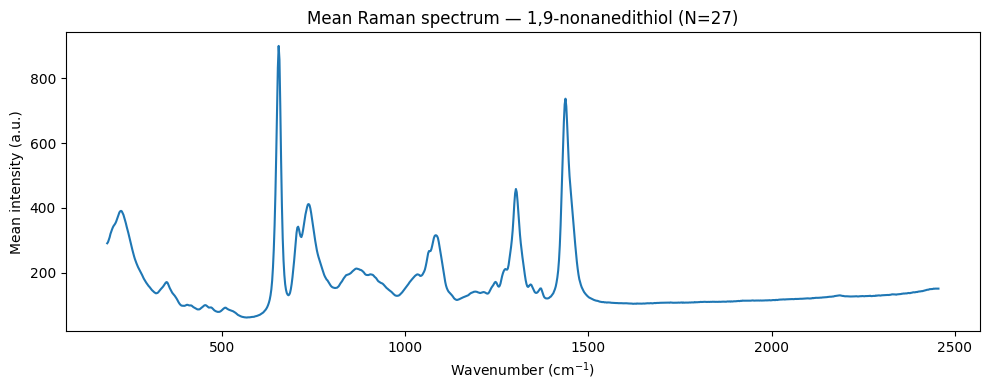

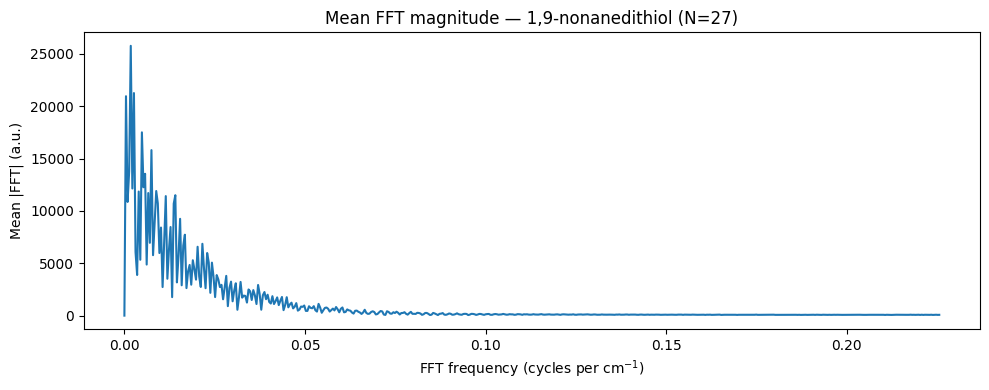

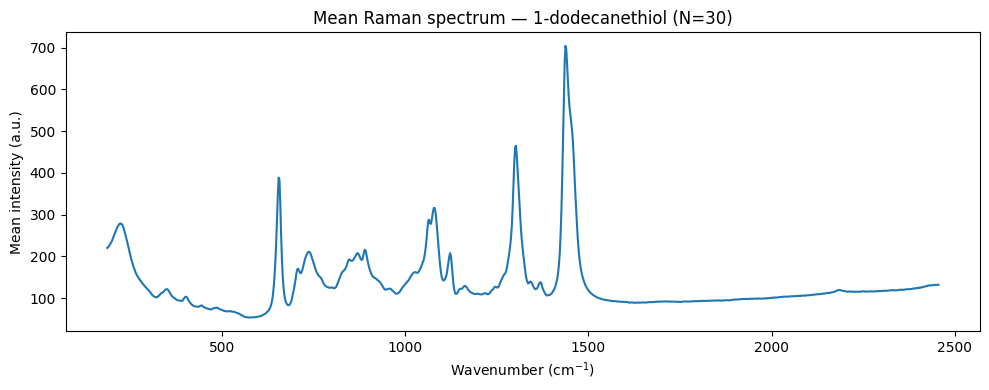

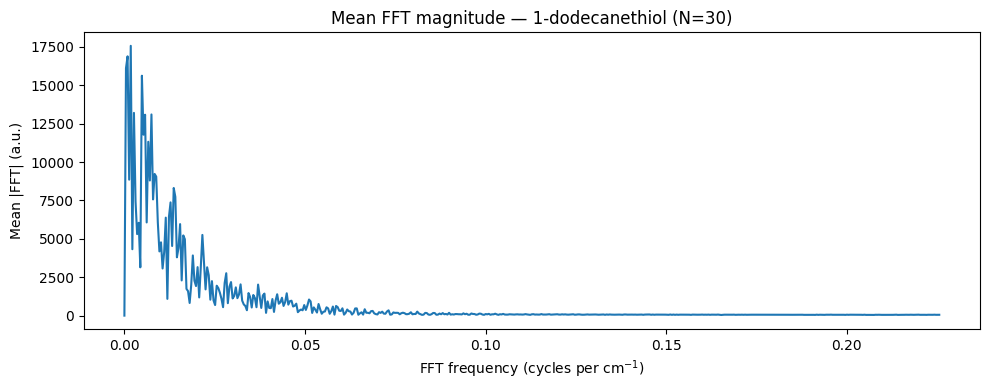

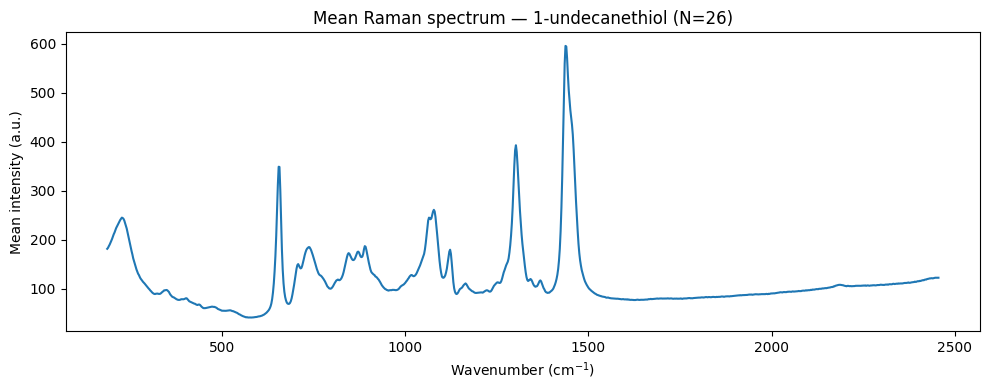

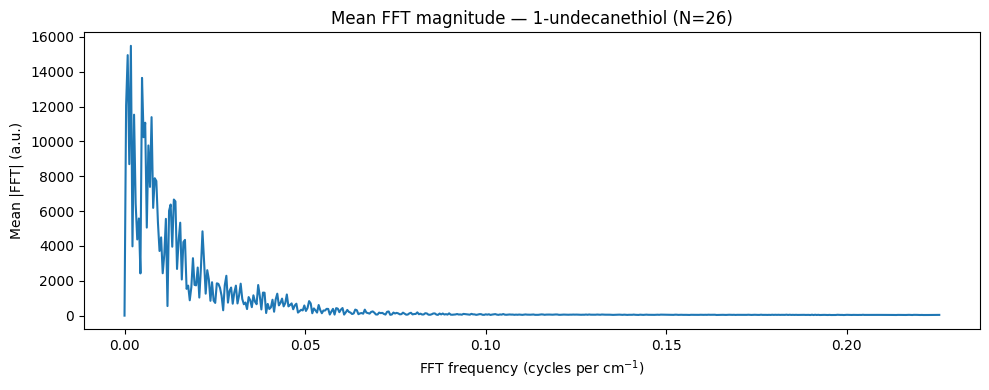

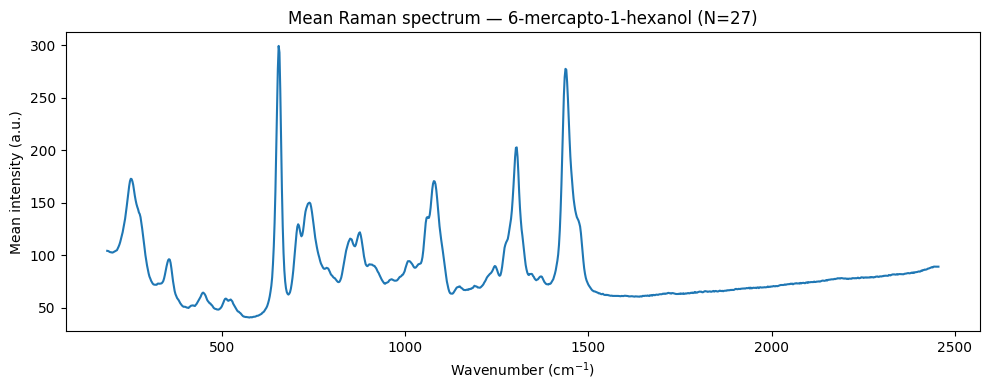

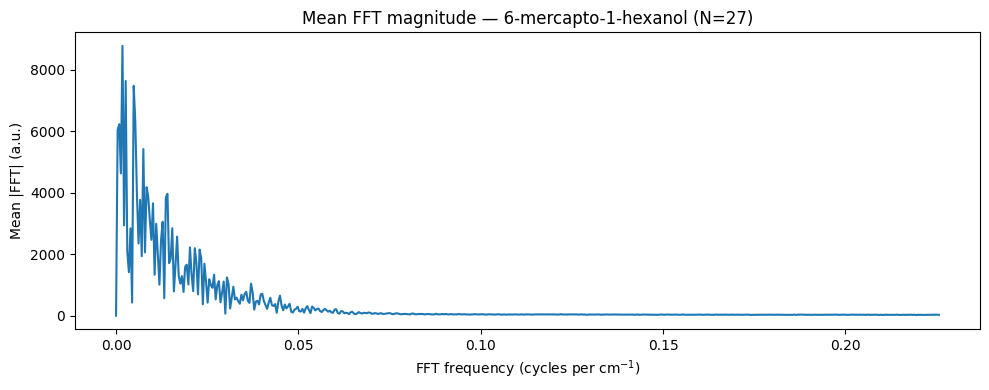

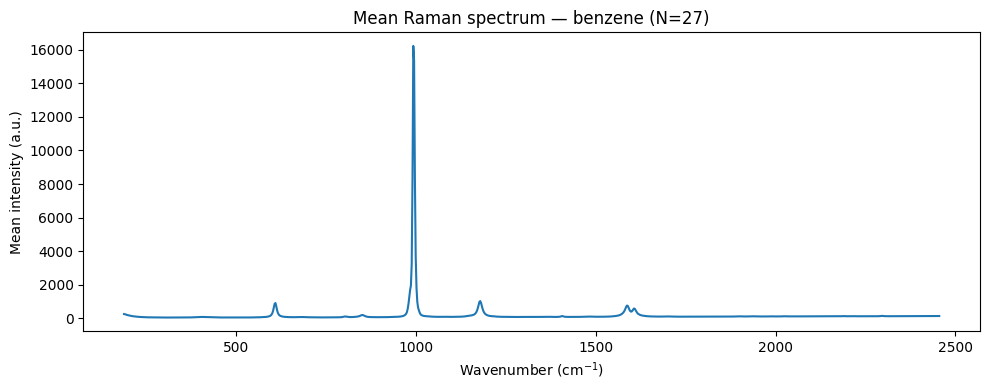

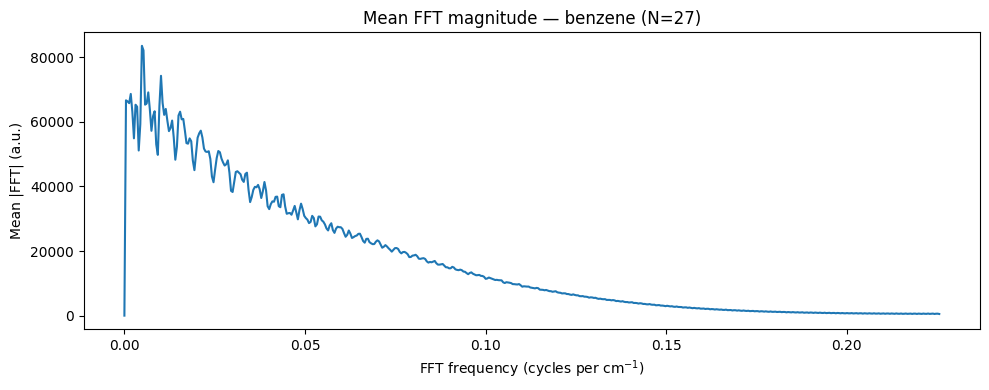

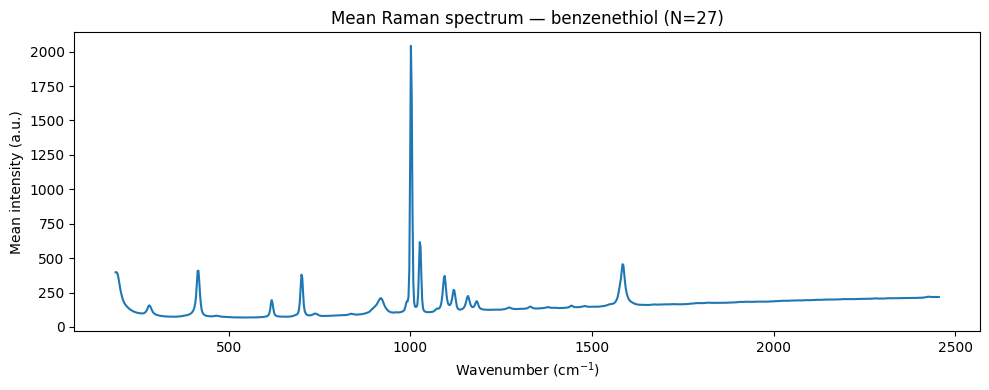

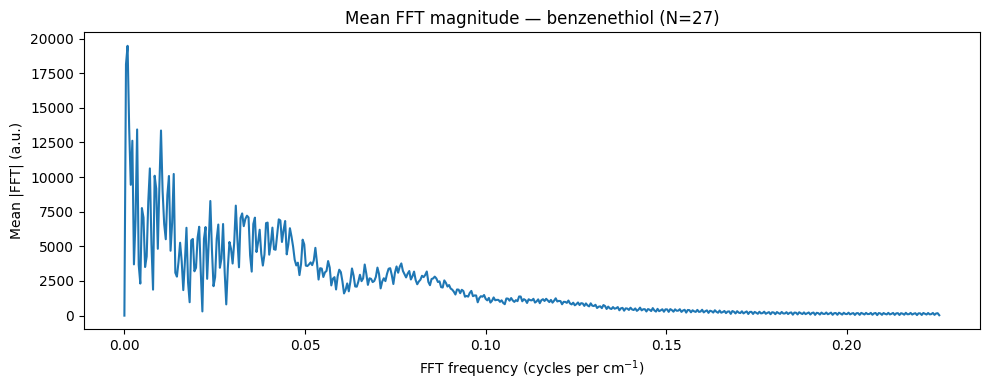

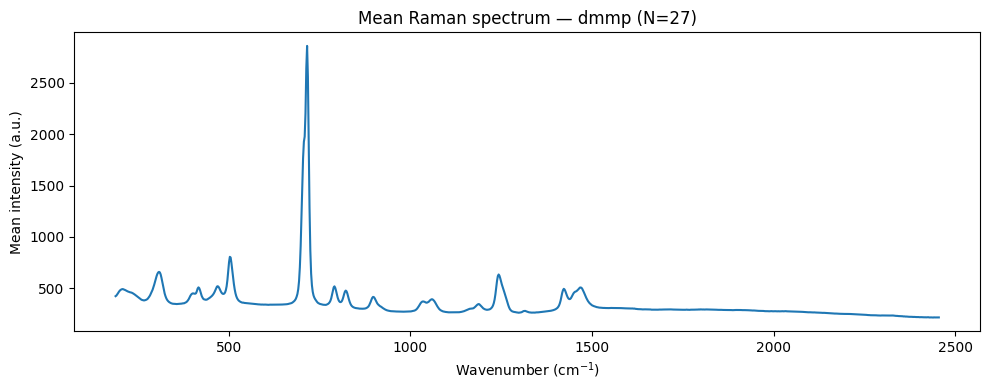

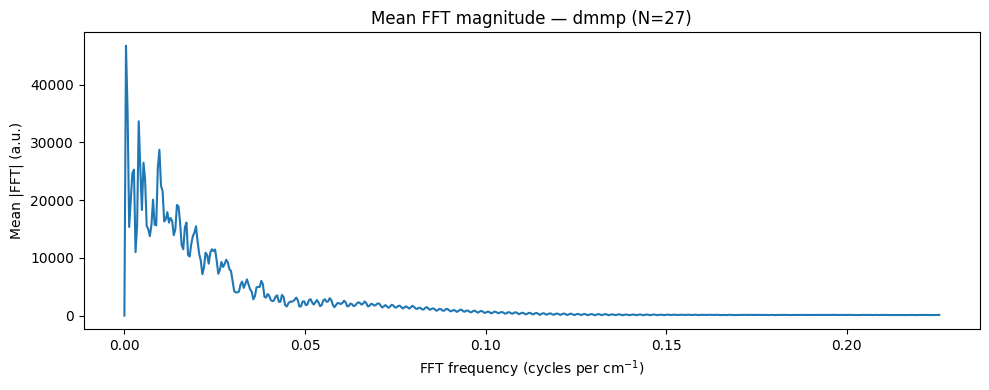

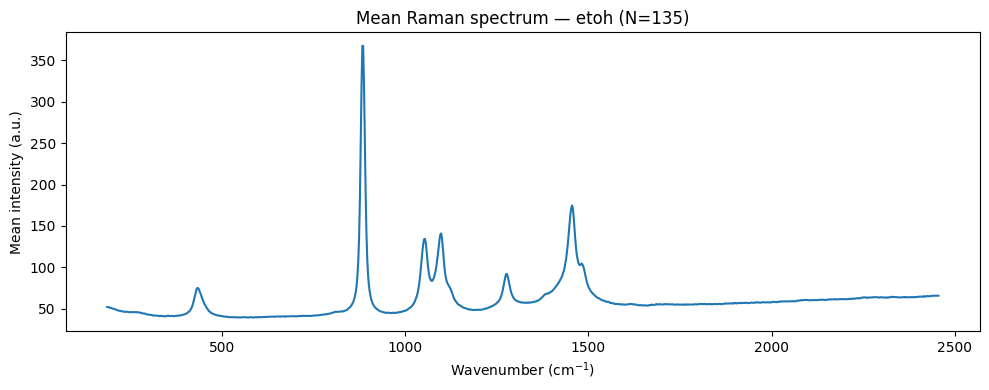

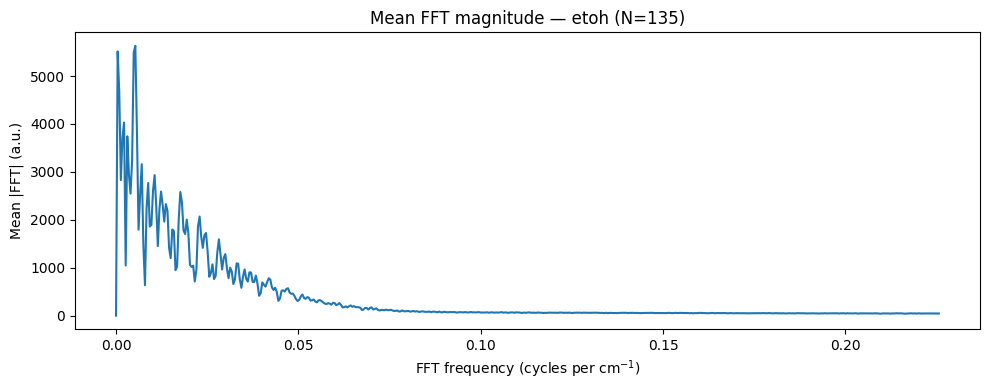

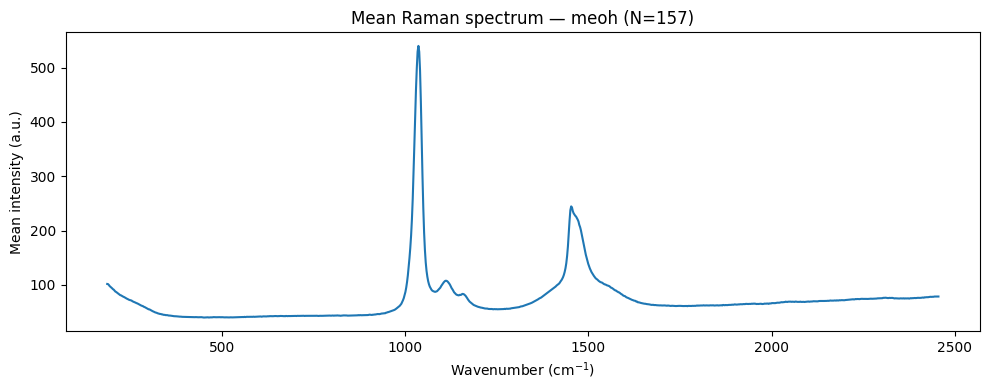

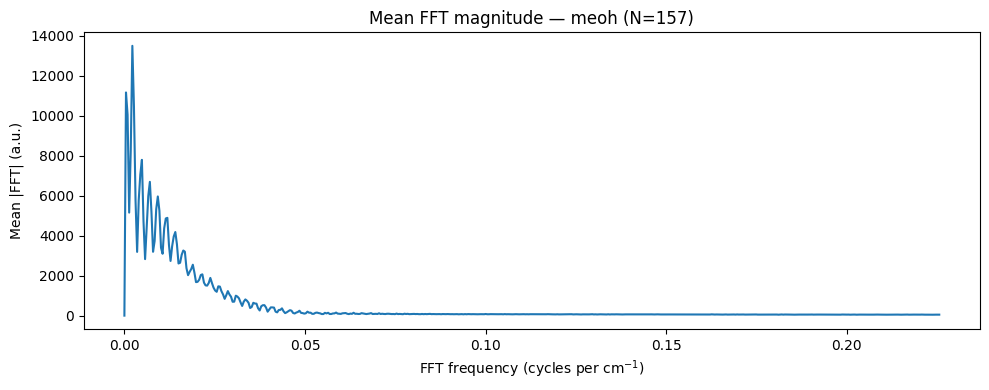

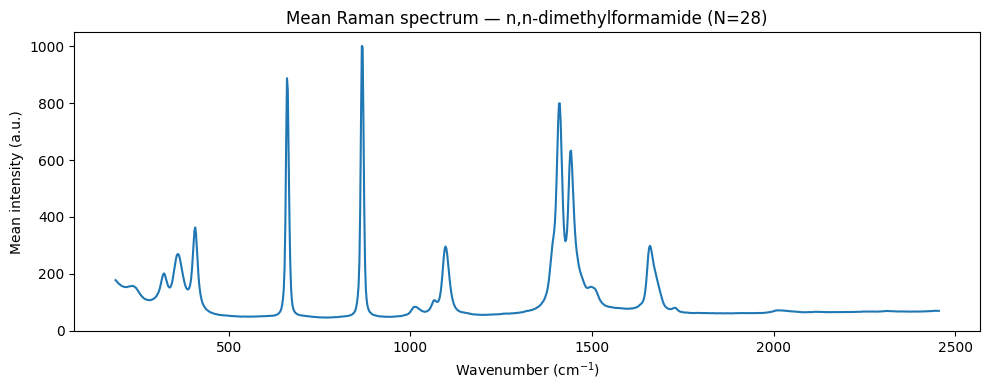

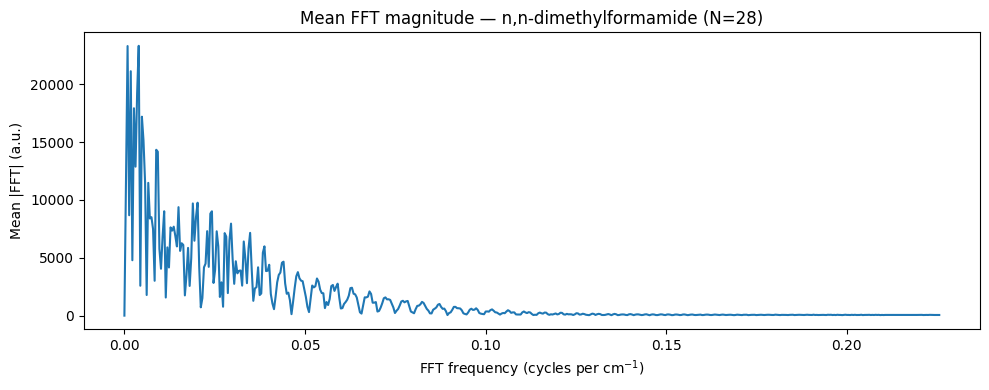

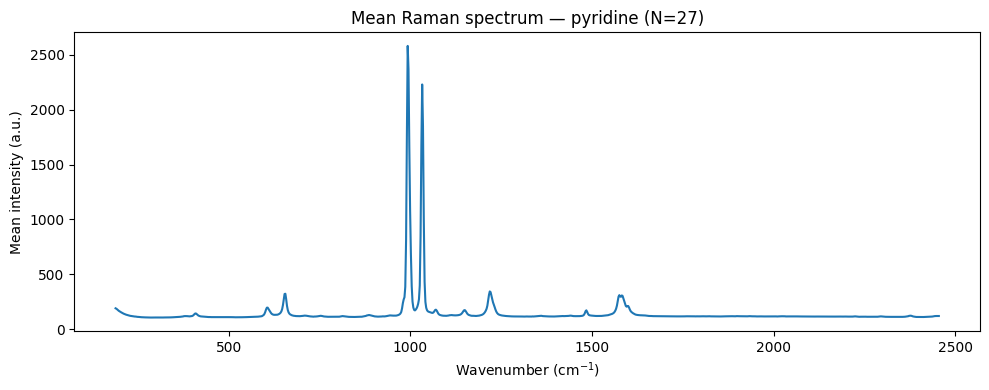

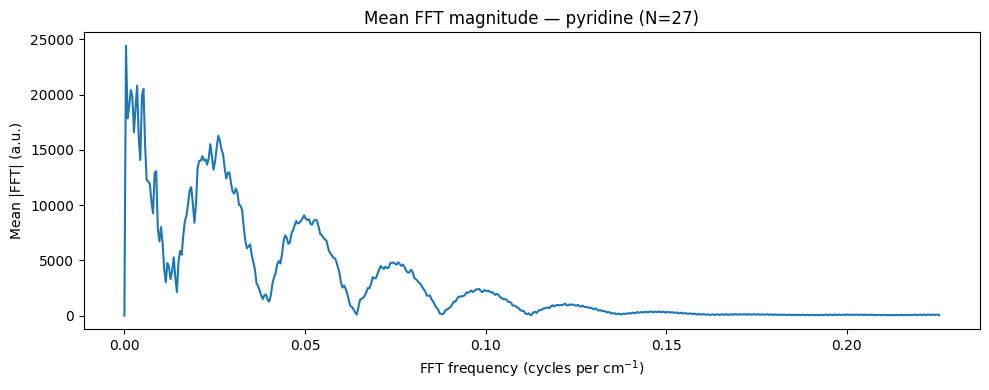

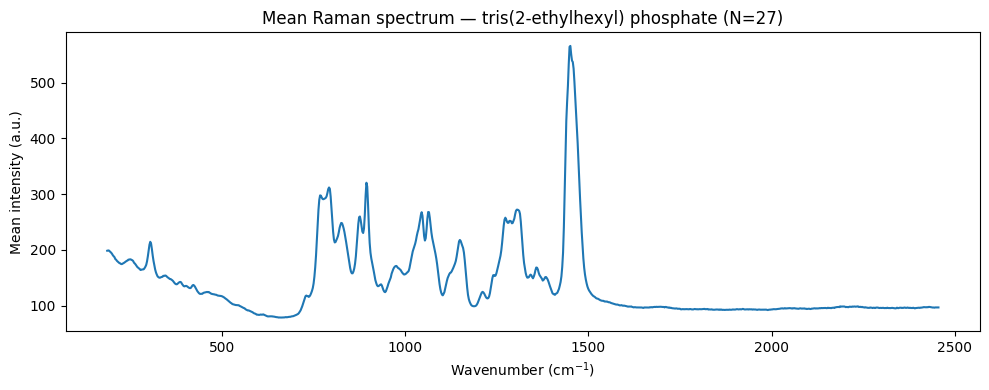

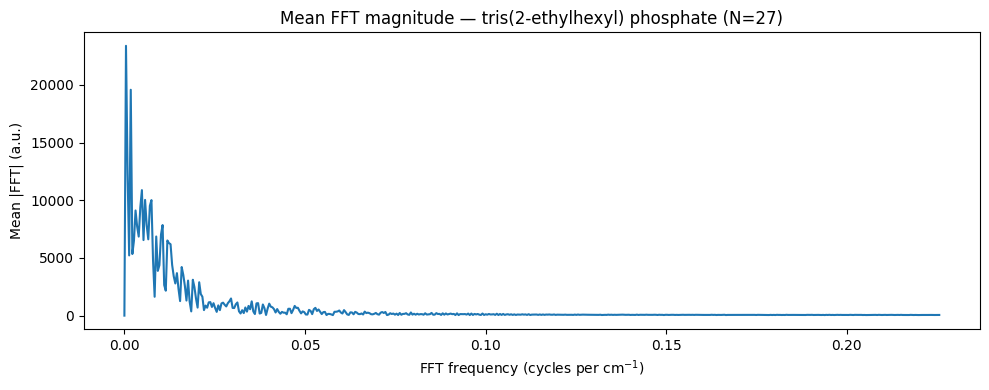

                       Component  N samples
0                           meoh        157
1                           etoh        135
2                1-dodecanethiol         30
3          n,n-dimethylformamide         28
4              1,9-nonanedithiol         27
5           6-mercapto-1-hexanol         27
6                        benzene         27
7                   benzenethiol         27
8                           dmmp         27
9                       pyridine         27
10  tris(2-ethylhexyl) phosphate         27
11               1-undecanethiol         26
Saved to: reference_component_plots
Label column used: Label


In [2]:
# --- Load single-component reference dataset ---
path = "reference_v2.csv"          # or "/mnt/data/reference_v2.csv" in your environment
df = pd.read_csv(path)

# --- Identify spectral (wavenumber) columns vs label/metadata columns ---
def is_float_colname(s):
    try:
        float(str(s).strip())
        return True
    except Exception:
        return False

spec_cols = [c for c in df.columns if is_float_colname(c)]
meta_cols = [c for c in df.columns if c not in spec_cols]

# Choose the label column (single-component): default = first metadata column
# If your label column has a specific name (e.g., "Label"), set it explicitly.
label_col = 'Label'  # e.g., replace with: label_col = "Label"

# --- Sort spectral columns by wavenumber ---
wavenumbers = np.array([float(c) for c in spec_cols])
order = np.argsort(wavenumbers)
wavenumbers = wavenumbers[order]
spec_cols = [spec_cols[i] for i in order]

X = df[spec_cols].to_numpy(dtype=float)

# Key for grouping (single component)
key = df[label_col].astype(str)

# FFT settings
n = X.shape[1]
dx = float(np.mean(np.diff(wavenumbers)))   # assumes ~uniform spacing
freq = np.fft.rfftfreq(n, d=dx)             # cycles per (cm^-1)

# --- Output control (no PdfPages) ---
SAVE_PNGS = True
SHOW_PLOTS = True
out_dir = "reference_component_plots"
if SAVE_PNGS:
    os.makedirs(out_dir, exist_ok=True)

def safe_name(s: str) -> str:
    return re.sub(r"[^a-zA-Z0-9._-]+", "_", s).strip("_")

summary = []

for component, idx in key.groupby(key).groups.items():
    Xi = X[np.array(list(idx))]

    # Mean spectrum
    mean_spec = Xi.mean(axis=0)

    # Mean FFT magnitude of demeaned spectra (same “first rendition” logic)
    Xi_demean = Xi - Xi.mean(axis=1, keepdims=True)
    mag = np.abs(np.fft.rfft(Xi_demean, axis=1))
    mean_mag = mag.mean(axis=0)

    summary.append({"Component": component, "N samples": len(idx)})

    tag = safe_name(component)

    # Plot 1: Mean spectrum
    plt.figure(figsize=(10, 4))
    plt.plot(wavenumbers, mean_spec)
    plt.xlabel("Wavenumber (cm$^{-1}$)")
    plt.ylabel("Mean intensity (a.u.)")
    plt.title(f"Mean Raman spectrum — {component} (N={len(idx)})")
    plt.tight_layout()
    if SAVE_PNGS:
        plt.savefig(os.path.join(out_dir, f"{tag}__mean_spectrum.png"), dpi=200)
    if SHOW_PLOTS:
        plt.show()
    plt.close()

    # Plot 2: Mean FFT magnitude
    plt.figure(figsize=(10, 4))
    plt.plot(freq, mean_mag)
    plt.xlabel("FFT frequency (cycles per cm$^{-1}$)")
    plt.ylabel("Mean |FFT| (a.u.)")
    plt.title(f"Mean FFT magnitude — {component} (N={len(idx)})")
    plt.tight_layout()
    if SAVE_PNGS:
        plt.savefig(os.path.join(out_dir, f"{tag}__mean_fft_mag.png"), dpi=200)
    if SHOW_PLOTS:
        plt.show()
    plt.close()

summary_df = (
    pd.DataFrame(summary)
    .sort_values(["N samples", "Component"], ascending=[False, True])
    .reset_index(drop=True)
)

print(summary_df)
print("Saved to:", out_dir if SAVE_PNGS else "(not saving)")
print("Label column used:", label_col)
